In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습곡선
from sklearn.model_selection import learning_curve

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score

# 피처 선택 ################################################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

### 차원의 저주

In [4]:
from scipy.spatial.distance import pdist

# 데이터의 개수
n_samples = 500
# 피처의 개수, 공간의 차원
# 1차원에서 100차원까지 5씩 증가
dimension = np.arange(1,101,5)

In [8]:
avg_distances = []
min_distances = []
# 차원별 거리 계산
for d in dimension :
    # 0과 1사이의 랜덤한 데이터를 생성(d차원)
    X = np.random.rand(n_samples,d)
    # 데이터들 간의 모든 거리를 계산한다.
    distances = pdist(X,metric='euclidean')
    # 거리 평균
    avg_distances.append(np.mean(distances))
    # 최소 거리
    min_distances.append(np.min(distances))

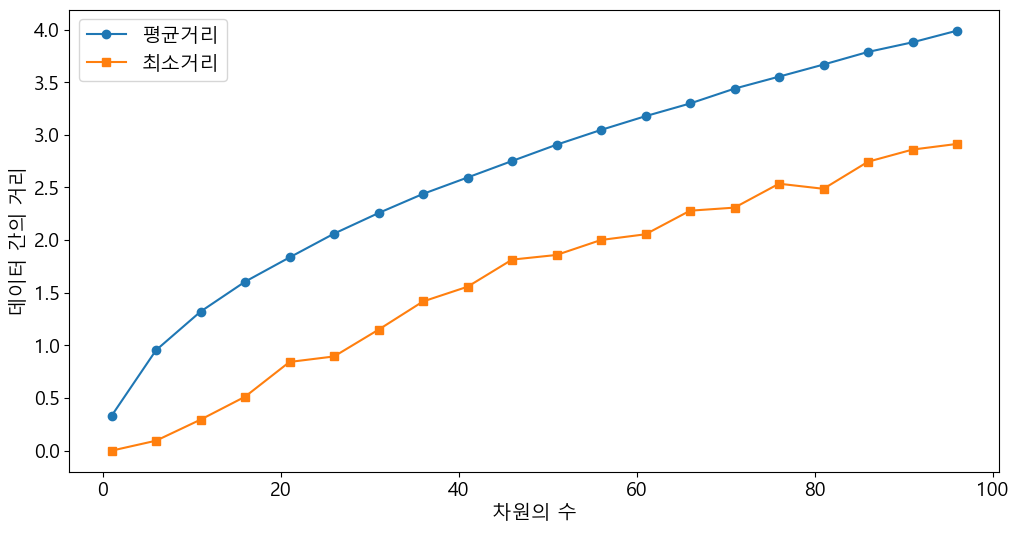

In [10]:
plt.plot(dimension, avg_distances, 'o-', label='평균거리')
plt.plot(dimension, min_distances, 's-', label='최소거리')
plt.xlabel('차원의 수')
plt.ylabel('데이터 간의 거리')
plt.legend()
plt.show()

### 분산 선택 (Variance Threshold) 연습
- 유방암 데이터에는 수십 개의 피처가 있다.
- 만약 어떤 피처의 값이 샘플마다 거의 변하지 않는다면, 암 여부를 판단하는데 아무런 도움이 되지 않는다.

In [12]:
from sklearn.datasets import load_breast_cancer

# 데이터를 가져온다.
data =load_breast_cancer()
df = pd.DataFrame(data.data,columns=data.feature_names)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [15]:
print(f'변환 전 피처의 개수 : {df.shape[1]}')

변환 전 피처의 개수 : 30


In [17]:
# 분산 선택 적용
# threshold : 분산의 임계치. 분산이 이 값보다 낮은 컬럼들은 제외한다.
# 분산이 낮다라는 것은 데이터들이 평균과 매우 유사하다는 의미이다. 즉 컬럼내의 데이터가 변동선이 거의없다라고 본다.
selector = VarianceThreshold(threshold=0.01)
selector.fit(df)

,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.01


In [20]:
# 결과를 확인한다
# VarianceThreshold.get_support 함수 : 각 컬럼별 분산이 임계치 보다 낮지 않은가를 확인
# 분산의 임계치보다 분산이 높은 컬럼들의 데이터만 가져온다.
selected_df = df.iloc[:, selector.get_support()]
selected_df

,mean radius,mean texture,mean perimeter,mean area,radius error,texture error,perimeter error,area error,worst radius,worst texture,worst perimeter,worst area,worst compactness,worst concavity
0,17.99,10.38,122.80,1001.0,1.0950,0.9053,8.589,153.40,25.380,17.33,184.60,2019.0,0.66560,0.7119
1,20.57,17.77,132.90,1326.0,0.5435,0.7339,3.398,74.08,24.990,23.41,158.80,1956.0,0.18660,0.2416
2,19.69,21.25,130.00,1203.0,0.7456,0.7869,4.585,94.03,23.570,25.53,152.50,1709.0,0.42450,0.4504
3,11.42,20.38,77.58,386.1,0.4956,1.1560,3.445,27.23,14.910,26.50,98.87,567.7,0.86630,0.6869
4,20.29,14.34,135.10,1297.0,0.7572,0.7813,5.438,94.44,22.540,16.67,152.20,1575.0,0.20500,0.4000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,1.1760,1.2560,7.673,158.70,25.450,26.40,166.10,2027.0,0.21130,0.4107
565,20.13,28.25,131.20,1261.0,0.7655,2.4630,5.203,99.04,23.690,38.25,155.00,1731.0,0.19220,0.3215
566,16.60,28.08,108.30,858.1,0.4564,1.0750,3.425,48.55,18.980,34.12,126.70,1124.0,0.30940,0.3403
567,20.60,29.33,140.10,1265.0,0.7260,1.5950,5.772,86.22,25.740,39.42,184.60,1821.0,0.86810,0.9387


In [21]:
print(f'변환 후 피처 개수 : {selected_df.shape[1]}')
print(f'제거된 피처 : {set(df.columns) - set(selected_df.columns)}')

변환 후 피처 개수 : 14
제거된 피처 : {'smoothness error', 'worst smoothness', 'compactness error', 'worst fractal dimension', 'mean compactness', 'mean fractal dimension', 'mean concavity', 'concave points error', 'concavity error', 'mean concave points', 'mean symmetry', 'fractal dimension error', 'worst symmetry', 'worst concave points', 'symmetry error', 'mean smoothness'}


In [22]:
# 각 컬럼별 분산
df.var()

mean radius                    12.418920
mean texture                   18.498909
mean perimeter                590.440480
mean area                  123843.554318
mean smoothness                 0.000198
mean compactness                0.002789
mean concavity                  0.006355
mean concave points             0.001506
mean symmetry                   0.000752
mean fractal dimension          0.000050
radius error                    0.076902
texture error                   0.304316
perimeter error                 4.087896
area error                   2069.431583
smoothness error                0.000009
compactness error               0.000321
concavity error                 0.000911
concave points error            0.000038
symmetry error                  0.000068
fractal dimension error         0.000007
worst radius                   23.360224
worst texture                  37.776483
worst perimeter              1129.130847
worst area                 324167.385102
worst smoothness

### 상관관계와 다중공선성 실습
- 당뇨병 데이터셋을 통해 피처 간의 상관관계를 분석한다.
- 서로 너무 밀접하게 연관된 피처는 모델의 해석력을 떨어뜨리고 계산량만 늘린다.(다중 공선성)

In [23]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
df_dia = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)
df_dia


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [24]:
# 상관계수 행렬을 생성한다.(피어슨 상관계수)
corr_matrix = df_dia.corr()
corr_matrix

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


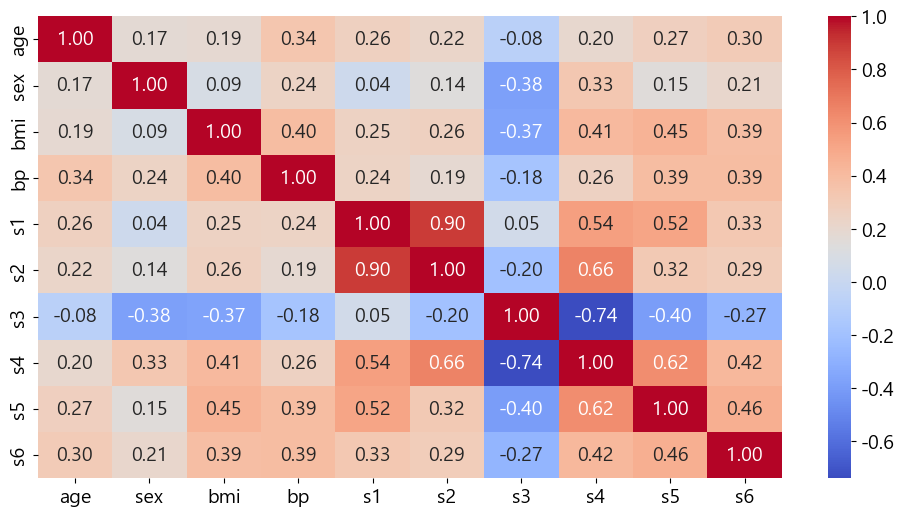

In [28]:
# 히트맵
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.show()

In [39]:
# 상관관계가 높은 (0.7 이상) 피처 쌍 찾아내기
for i in range(len(corr_matrix.columns)) :
    for j in range(i) :
        if abs(corr_matrix.iloc[i,j]) > 0.7 :
            col_name = corr_matrix.columns[i]
            row_name = corr_matrix.columns[j]
            print(f'{row_name} - {col_name} : {corr_matrix.iloc[i,j]:.2f}')


s1 - s2 : 0.90
s3 - s4 : -0.74


### RFE

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer

In [42]:
# 데이터를 불러온다.
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

In [43]:
# 모델을 생성한다.
model = LogisticRegression(max_iter = 5000)

In [45]:
# RFE 실행(5개만 남겨라~~ 학습에 도움되는 컬럼 5개만 남기라고 하는 것)
rfe = RFE(estimator=model, n_features_to_select=5)
rfe.fit(X,y)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...max_iter=5000)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",5
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


In [48]:
# 선택한 피처
cancer.feature_names[rfe.support_]

array(['mean radius', 'texture error', 'worst radius',
       'worst compactness', 'worst concavity'], dtype='<U23')

In [54]:
# 각 피처별 우선순위
d1 = {
    'feature_names' : cancer.feature_names,
    'rank' : rfe.ranking_
}
rank_df = pd.DataFrame(d1)
rank_df.sort_values('rank', inplace=True)
rank_df

,feature_names,rank
0,mean radius,1
11,texture error,1
25,worst compactness,1
20,worst radius,1
26,worst concavity,1
27,worst concave points,2
28,worst symmetry,3
6,mean concavity,4
5,mean compactness,5
24,worst smoothness,6


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
X = pd.DataFrame(X, columns=cancer.feature_names)

train_X, test_X, train_y,test_y = train_test_split(X, y, test_size=0.3, random_state=42)

model1 = LogisticRegression(max_iter=5000)
model2 = LogisticRegression(max_iter=5000)

model1.fit(train_X,train_y)
model2.fit(train_X[cancer.feature_names[rfe.support_]],train_y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [62]:
# 예측
pred1 = model1.predict(test_X)
pred2 = model2.predict(test_X[cancer.feature_names[rfe.support_]])

# 평가
score1 = f1_score(test_y, pred1)
score2 = f1_score(test_y, pred2)

print(score1)
print(score2)

0.9814814814814815
0.9861751152073732


### Permutation Importance : 모델 해석력 강화

In [64]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

In [65]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

In [66]:
# 학습데이터와 테스트 데이터 분류
X_train,X_test,y_train,y_test = train_test_split(X,y, random_state=42)

In [67]:
# 모델 학습
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [69]:
# Permutation Importance 계산
# n_repeats = 10 : 각 피처를 10번 무작위로 섞어서 평균적인 중요도를 측정한다.
result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

In [80]:
# 시각화를 위해서 데이터를 정렬
sorted_idx = result.importances_mean.argsort()
# 상위 10개만!
# top10_idx = sorted_idx[:10]
# 전체
top10_idx = sorted_idx

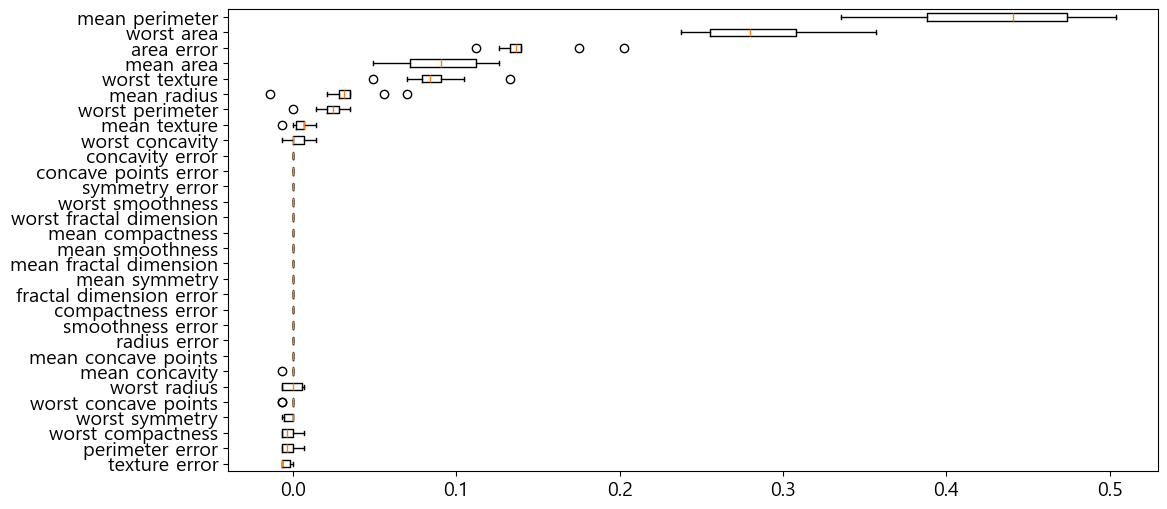

In [81]:
plt.boxplot(
    result.importances[top10_idx].T,
    vert=False,
    tick_labels=feature_names[top10_idx]
)
plt.show()

- 0을 기준으로 오른쪽에 있다면 : 가장 주요한 피처이다 (살린다)
- 0을 기준으로 왼쪽에 있다면 : 모델을 방해하는 노이즈이다(죽인다)
- 0을 기준으로 좌우에 걸쳐있다면 : 있어도 그만, 없어도 그만인 피쳐이다, 학습에 심한 방해가 되지는 않지만 괜히 계산량만 늘린다.

### RFE와 Permutation Importance의 결과가 다른 이유
- RFE는 모델 학습 중 하나씩 제거하면서 판단하며 Permutation Importance는 모델 학습 후에 평가하는 방식이다.
- 이러한 차이 때문에 다중 공선성의 문제가 있는 데이터를 사용할 경우 둘은 차이를 보인다.
- 가장 먼저 다중 공선성의 문제를 해결하세요
- 그 다음에 목적에 따라 사용한다.
- "컬럼의 개수를 줄여서 모델을 가볍게 하고자한다면" -> RFE 결과를 따르세요 (중복된 컬럼을 잘 쳐낸다)
- "이 모델이 왜 이런 예측을 했는지 보고해야 한다면" -> Permutation Importance가 더 직관적이다